In [56]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
import os
#import importlib
#import plots_functions

from matplotlib.ticker import FuncFormatter

sys.path.insert(0, os.path.abspath('..'))

sys.path.append("/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/functions")

#importlib.reload(plots_functions)

from data_cleaning_functions import missing_value_report
from outlier_functions import (iqr_bounds, flag_outliers, filter_outliers)
from plots_functions import (plot_missing_values, plot_boxplots, plot_histograms, plot_sold_distributions)
from feature_engineering_functions import add_market_condition, add_price_reduction_flags, add_dom_buckets, add_price_tiers

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Load Data

In [57]:
listings_original = pd.read_csv('/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/CRMLSListing/CRMLSListing_Master_Residential.csv', low_memory=False)
listings = listings_original.copy()

sold_original = pd.read_csv('/Users/cynthiagao/PycharmProjects/IDX Exchange Internship/IDX Files/CRMLSSold/CRMLSSold_Master_Residential.csv', low_memory=False)
sold = sold_original.copy()

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 397,603 rows x 84 columns
Listings shape:      540,183 rows x 84 columns


In [58]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 540183 entries, 0 to 540182
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             539409 non-null  float64
 1   ListingKey                    540183 non-null  int64  
 2   ListAgentEmail                493182 non-null  str    
 3   CloseDate                     165822 non-null  str    
 4   ClosePrice                    145580 non-null  float64
 5   ListAgentFirstName            535958 non-null  str    
 6   ListAgentLastName             540144 non-null  str    
 7   Latitude                      460038 non-null  float64
 8   Longitude                     460038 non-null  float64
 9   UnparsedAddress               539513 non-null  str    
 10  PropertyType                  540183 non-null  str    
 11  LivingArea                    539627 non-null  float64
 12  ListPrice                     540183 non-null  float64


In [59]:
listings.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,Latitude.1,ListPrice.1,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,5.394090e+05,5.401830e+05,1.455800e+05,460038.000000,460038.000000,5.396270e+05,5.401830e+05,540183.000000,0.0,0.0,...,460038.000000,5.401830e+05,0.0,445934.000000,4.965040e+05,294108.000000,510192.000000,410521.000000,4.963290e+05,0.0
mean,1.397125e+06,1.104799e+09,1.202136e+06,34.602361,-118.456467,1.980059e+03,1.312997e+06,19.539904,NaN,NaN,...,34.602361,1.312997e+06,NaN,1.371021,4.695352e+04,2.046854,1.845109,270.781486,4.110303e+05,NaN
std,7.357159e+06,2.988384e+07,4.292686e+06,1.997955,3.600223,2.338269e+04,2.346687e+06,26.771154,NaN,NaN,...,1.997955,2.346687e+06,NaN,0.483079,2.178790e+06,6.437679,3.878483,2369.065120,2.080337e+07,NaN
min,0.000000e+00,1.018357e+09,5.250000e+02,-117.472493,-159.475987,0.000000e+00,1.000000e+02,-58.000000,NaN,NaN,...,-117.472493,1.000000e+02,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,5.850000e+05,1.077379e+09,6.000000e+05,33.739794,-118.679866,1.247000e+03,5.800000e+05,5.000000,NaN,NaN,...,33.739794,5.800000e+05,NaN,1.000000,5.000000e+03,1.000000,1.000000,0.000000,5.227000e+03,NaN
50%,8.490000e+05,1.104806e+09,8.550000e+05,34.053081,-118.026692,1.669000e+03,8.400000e+05,11.000000,NaN,NaN,...,34.053081,8.400000e+05,NaN,1.000000,7.196000e+03,2.000000,2.000000,125.000000,7.405000e+03,NaN
75%,1.389000e+06,1.126880e+09,1.350000e+06,34.473541,-117.237403,2.300000e+03,1.375000e+06,23.000000,NaN,NaN,...,34.473541,1.375000e+06,NaN,2.000000,1.205100e+04,3.000000,2.000000,400.000000,1.361500e+04,NaN
max,1.390000e+09,1.157178e+09,8.200000e+08,737.000000,329.000000,1.702132e+07,1.950000e+08,731.000000,NaN,NaN,...,737.000000,1.950000e+08,NaN,2.000000,9.187423e+08,3333.000000,600.000000,968348.000000,7.638115e+09,NaN


In [60]:
sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 397603 entries, 0 to 397602
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 348512 non-null  str    
 1   ListAgentAOR                  351417 non-null  str    
 2   Flooring                      255013 non-null  str    
 3   ViewYN                        363734 non-null  object 
 4   WaterfrontYN                  248 non-null     object 
 5   BasementYN                    7777 non-null    object 
 6   PoolPrivateYN                 363168 non-null  object 
 7   OriginalListPrice             396882 non-null  float64
 8   ListingKey                    397603 non-null  int64  
 9   ListAgentEmail                368591 non-null  str    
 10  CloseDate                     397603 non-null  str    
 11  ClosePrice                    397601 non-null  float64
 12  ListAgentFirstName            394604 non-null  str    


In [61]:
sold.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,BusinessType,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,BuyerAgencyCompensation
count,3.968820e+05,3.976030e+05,3.976010e+05,381781.000000,381781.000000,3.973740e+05,3.976030e+05,397603.000000,0.0,0.0,...,0.0,0.0,336100.000000,3.667400e+05,230762.000000,380550.000000,306605.000000,3.666160e+05,0.0,46125.000000
mean,1.224737e+06,1.095908e+09,1.185616e+06,34.652745,-118.569288,1.904351e+03,1.138630e+06,37.336788,NaN,NaN,...,NaN,NaN,1.364293,3.839295e+04,2.059000,1.858482,234.846032,3.347135e+05,NaN,221.929675
std,6.779804e+06,2.993458e+07,5.922380e+06,1.707144,2.956203,2.701781e+04,1.353707e+06,53.539245,NaN,NaN,...,NaN,NaN,0.481232,2.139732e+06,7.241926,3.706629,1772.302247,1.630672e+07,NaN,2590.406598
min,0.000000e+00,4.216785e+08,0.000000e+00,-117.472493,-177.646696,0.000000e+00,5.250000e+02,-288.000000,NaN,NaN,...,NaN,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN,0.000000
25%,5.850000e+05,1.075071e+09,5.750000e+05,33.736517,-118.880412,1.247000e+03,5.750000e+05,8.000000,NaN,NaN,...,NaN,NaN,1.000000,5.000000e+03,1.000000,2.000000,0.000000,5.227000e+03,NaN,2.000000
50%,8.250000e+05,1.093954e+09,8.200000e+05,34.046785,-118.014438,1.641000e+03,8.150000e+05,19.000000,NaN,NaN,...,NaN,NaN,1.000000,7.016000e+03,2.000000,2.000000,95.000000,7.242000e+03,NaN,2.500000
75%,1.299000e+06,1.115094e+09,1.300000e+06,34.553090,-117.267869,2.217000e+03,1.295000e+06,48.000000,NaN,NaN,...,NaN,NaN,2.000000,1.089000e+04,3.000000,2.000000,369.000000,1.182500e+04,NaN,2.500000
max,1.390000e+09,1.157159e+09,9.895000e+08,56.130366,329.000000,1.702132e+07,1.375000e+08,12430.000000,NaN,NaN,...,NaN,NaN,2.000000,9.187423e+08,3333.000000,600.000000,750000.000000,2.208318e+09,NaN,100000.000000


# 2. Clean Data

### 2a) Drop duplicate columns

In [7]:
# Drop duplicate columns

duplicate_cols_listing = [col for col in listings.columns if col.endswith('.1')]
listings = listings.drop(columns=duplicate_cols_listing)

duplicate_cols_sold = [col for col in sold.columns if col.endswith('.1')]
sold = sold.drop(columns=duplicate_cols_sold)

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 397,603 rows x 84 columns
Listings shape:      540,183 rows x 73 columns


### 2b) Check columns for missing values

In [8]:
listings_missing = missing_value_report(listings, "New Listings")

=== New Listings: 63 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         540183     100.00
FireplacesTotal                      540183     100.00
CoveredSpaces                        540183     100.00
BusinessType                         540183     100.00
ElementarySchoolDistrict             540183     100.00
...                                     ...        ...
StateOrProvince                          62       0.01
BathroomsTotalInteger                    55       0.01
ListAgentLastName                        39       0.01
ParkingTotal                             20       0.00
PostalCode                               13       0.00

[63 rows x 2 columns]


In [9]:
sold_missing = missing_value_report(sold, "Sold Transactions")

=== Sold Transactions: 73 columns with missing values ===
                              Missing Count  Missing %
MiddleOrJuniorSchoolDistrict         397603     100.00
CoveredSpaces                        397603     100.00
TaxYear                              397603     100.00
FireplacesTotal                      397603     100.00
AboveGradeFinishedArea               397603     100.00
...                                     ...        ...
ListAgentLastName                        40       0.01
PostalCode                                2       0.00
ListingContractDate                       1       0.00
ClosePrice                                2       0.00
BedroomsTotal                            11       0.00

[73 rows x 2 columns]


In [10]:
# Columns with more than 90% missing values

listing_cols_over_90_missing = listings_missing[listings_missing["Missing %"] > 90].index.tolist()
print(f"Listing Columns over 90% Missing = {listing_cols_over_90_missing}")

Listing Columns over 90% Missing = ['MiddleOrJuniorSchoolDistrict', 'FireplacesTotal', 'CoveredSpaces', 'BusinessType', 'ElementarySchoolDistrict', 'TaxYear', 'TaxAnnualAmount', 'AboveGradeFinishedArea', 'BelowGradeFinishedArea', 'CoBuyerAgentFirstName', 'BuilderName', 'LotSizeDimensions', 'BuildingAreaTotal']


In [11]:
sold_cols_over_90_missing = sold_missing[sold_missing["Missing %"] > 90].index.tolist()
print(f"Sold Columns over 90% Missing = {sold_cols_over_90_missing}")

Sold Columns over 90% Missing = ['MiddleOrJuniorSchoolDistrict', 'CoveredSpaces', 'TaxYear', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BusinessType', 'ElementarySchoolDistrict', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions', 'BuilderName', 'BuildingAreaTotal', 'CoBuyerAgentFirstName', 'OriginatingSystemSubName', 'OriginatingSystemName']


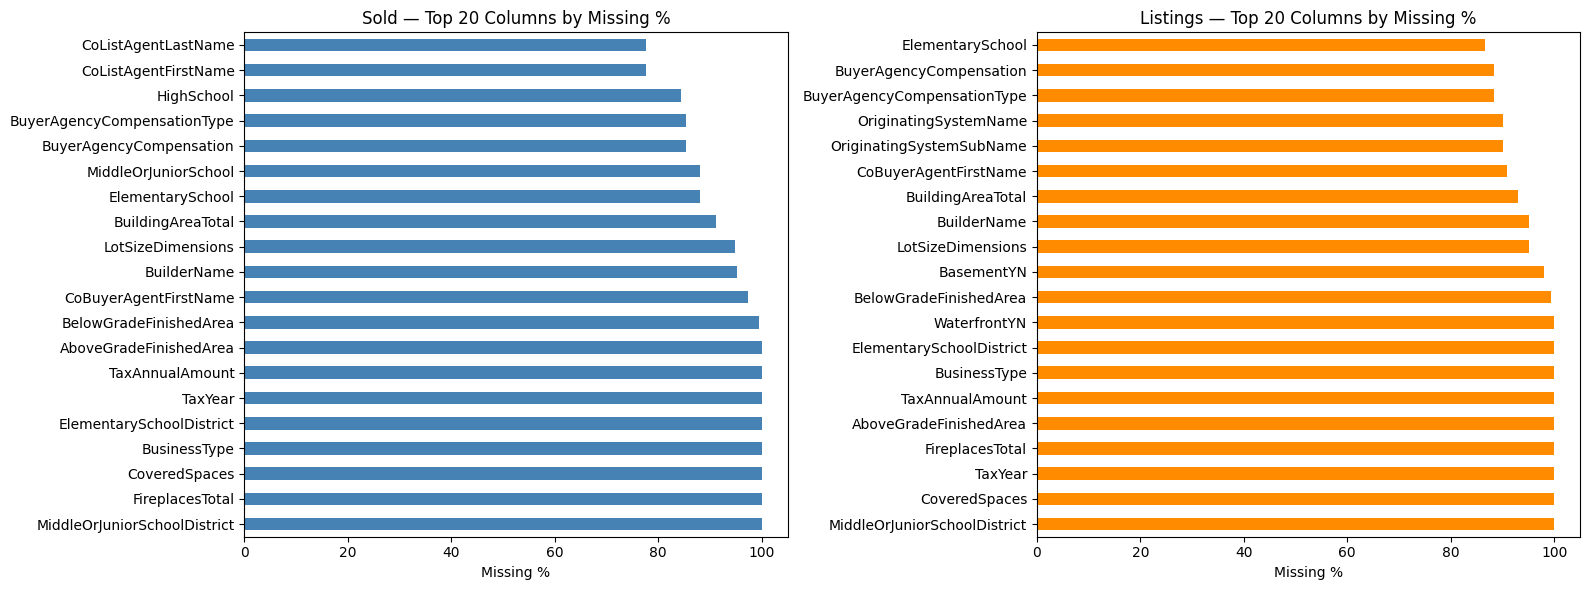

In [12]:
plot_missing_values(listings_missing, sold_missing)

We drop all columns with more than 90% missing values because none of the columns are one of the core variables like price, date, size, beds, baths, etc. These columns have no use to us if they are mostly empty.

In [13]:
# Drop columns with >90% missing
listings = listings.drop(columns=listing_cols_over_90_missing)

sold = sold.drop(columns=sold_cols_over_90_missing)

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")
print(f"Listings shape:      {listings.shape[0]:,} rows x {listings.shape[1]} columns")

Sold shape: 397,603 rows x 67 columns
Listings shape:      540,183 rows x 60 columns


### 2c) Change binary variables to 0s and 1s.

In [14]:
# Change YN columns to 0/1 Binary variables, with NaN = 0

YN_columns_listings = ['NewConstructionYN', 'FireplaceYN', 'AttachedGarageYN']

for col in YN_columns_listings:
    listings[col] = (
        listings[col]
        .replace({"Yes": 1, "No": 0})
        .fillna(0)
        .astype(int))

listings.head()

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,HighSchool,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,...,NaN,One,177861.0,NaN,0,NaN,NaN,90067,2105.00,177861.0
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,NaN,NaN,Renee,Chen,33.496363,-117.691677,16 Palisades,...,NaN,Two,5300.0,0.0,0,3.0,Capistrano Unified,92677,254.00,5300.0
2,3150000.0,1074936537,anader@dppre.com,NaN,NaN,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,...,NaN,Two,9404.0,NaN,0,2.0,NaN,91108,NaN,9404.0
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,NaN,NaN,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,...,Diamond Bar,ThreeOrMore,58232.0,1.0,0,4.0,Walnut Valley Unified,91765,295.95,58232.0
4,12725000.0,1074143166,jeff.williams@pacificsir.com,NaN,NaN,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,...,Corona Del Mar,ThreeOrMore,2250.0,3.0,0,2.0,Newport Mesa Unified,92662,0.00,2250.0


In [15]:
# Change YN columns to 0/1 Binary variables, with NaN = 0

YN_columns_sold = ['ViewYN', 'PoolPrivateYN', 'NewConstructionYN', 'FireplaceYN', 'AttachedGarageYN']

for col in YN_columns_sold:
    sold[col] = (
        sold[col]
        .replace({"True": 1, "False": 0})
        .fillna(0)
        .astype(int))

sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",1,0,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,0,1.0,Other,94401,6472.0,NaN,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,0,0,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,0,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,0,0,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,0,2.0,NaN,91950,NaN,NaN,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,0,0,NaN,1079166779,davidmartz@compass.com,2024-01-30,858000.0,...,0,2.0,Palm Springs Unified,92262,NaN,13504.0,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,0,0,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,0,2.0,Los Angeles Unified,91356,0.0,17873.0,NaN,NaN,NaN,NaN


### 2d) Check distributions and for outliers

In [16]:
target_columns = ["ClosePrice", "ListPrice","OriginalListPrice", "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]

#### i) Generate boxplots

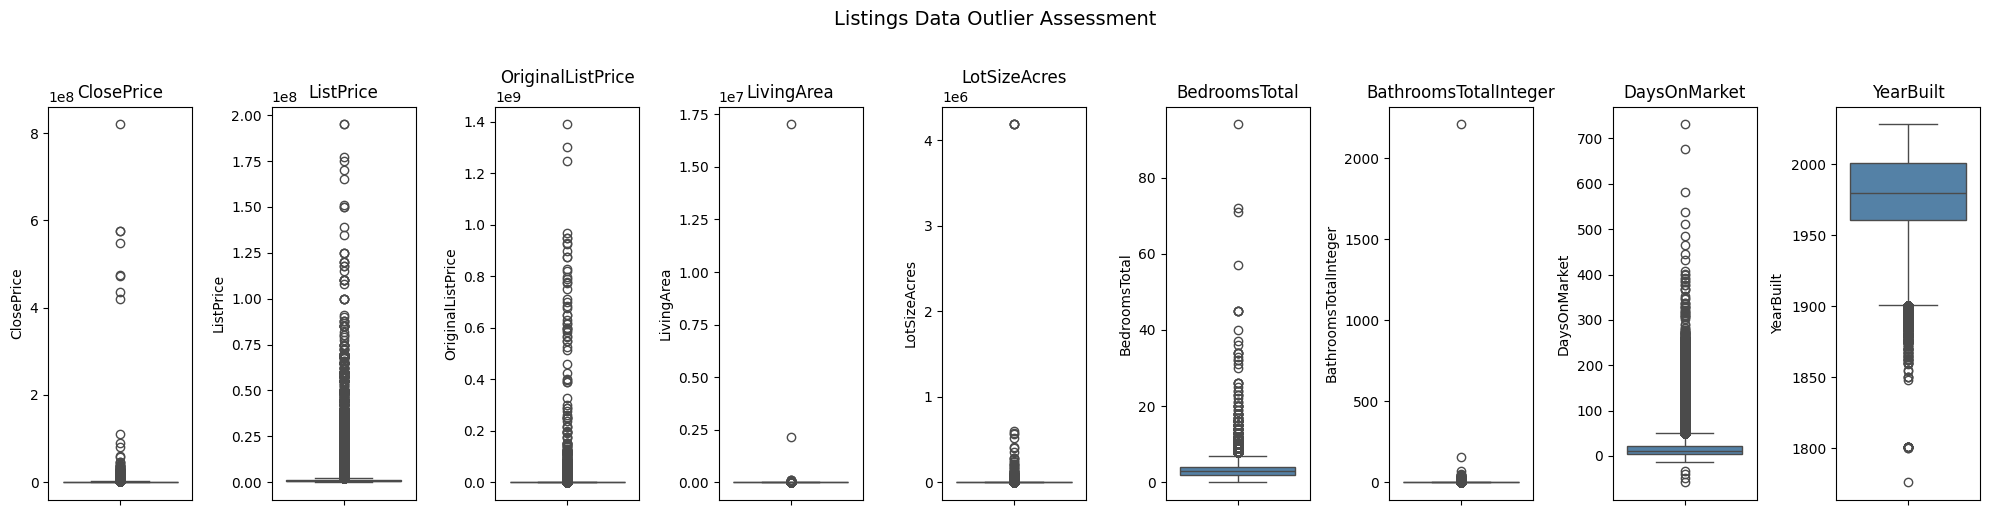

In [17]:
plot_boxplots(listings, target_columns, 'Listings Data Outlier Assessment', color = 'steelblue')

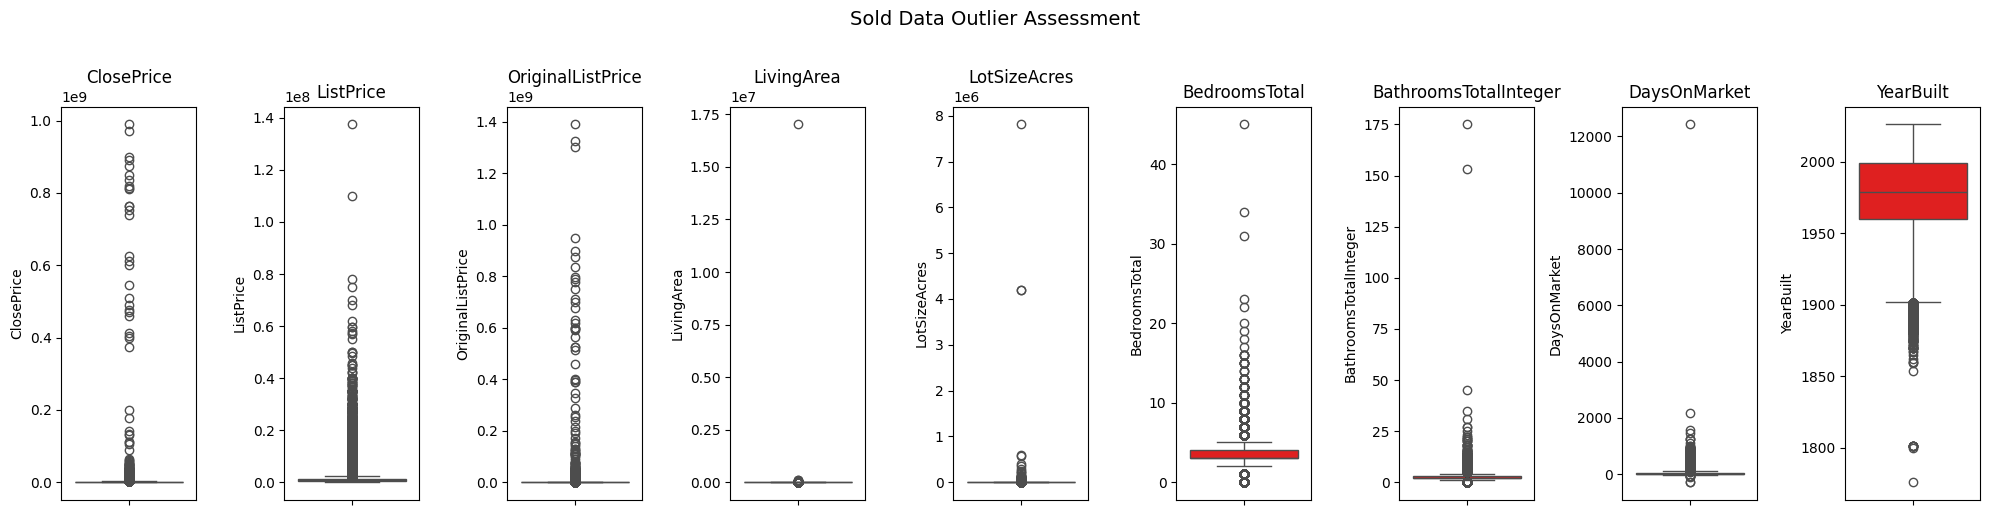

In [18]:
plot_boxplots(sold, target_columns, 'Sold Data Outlier Assessment', color = 'red')

#### ii) Generate histograms

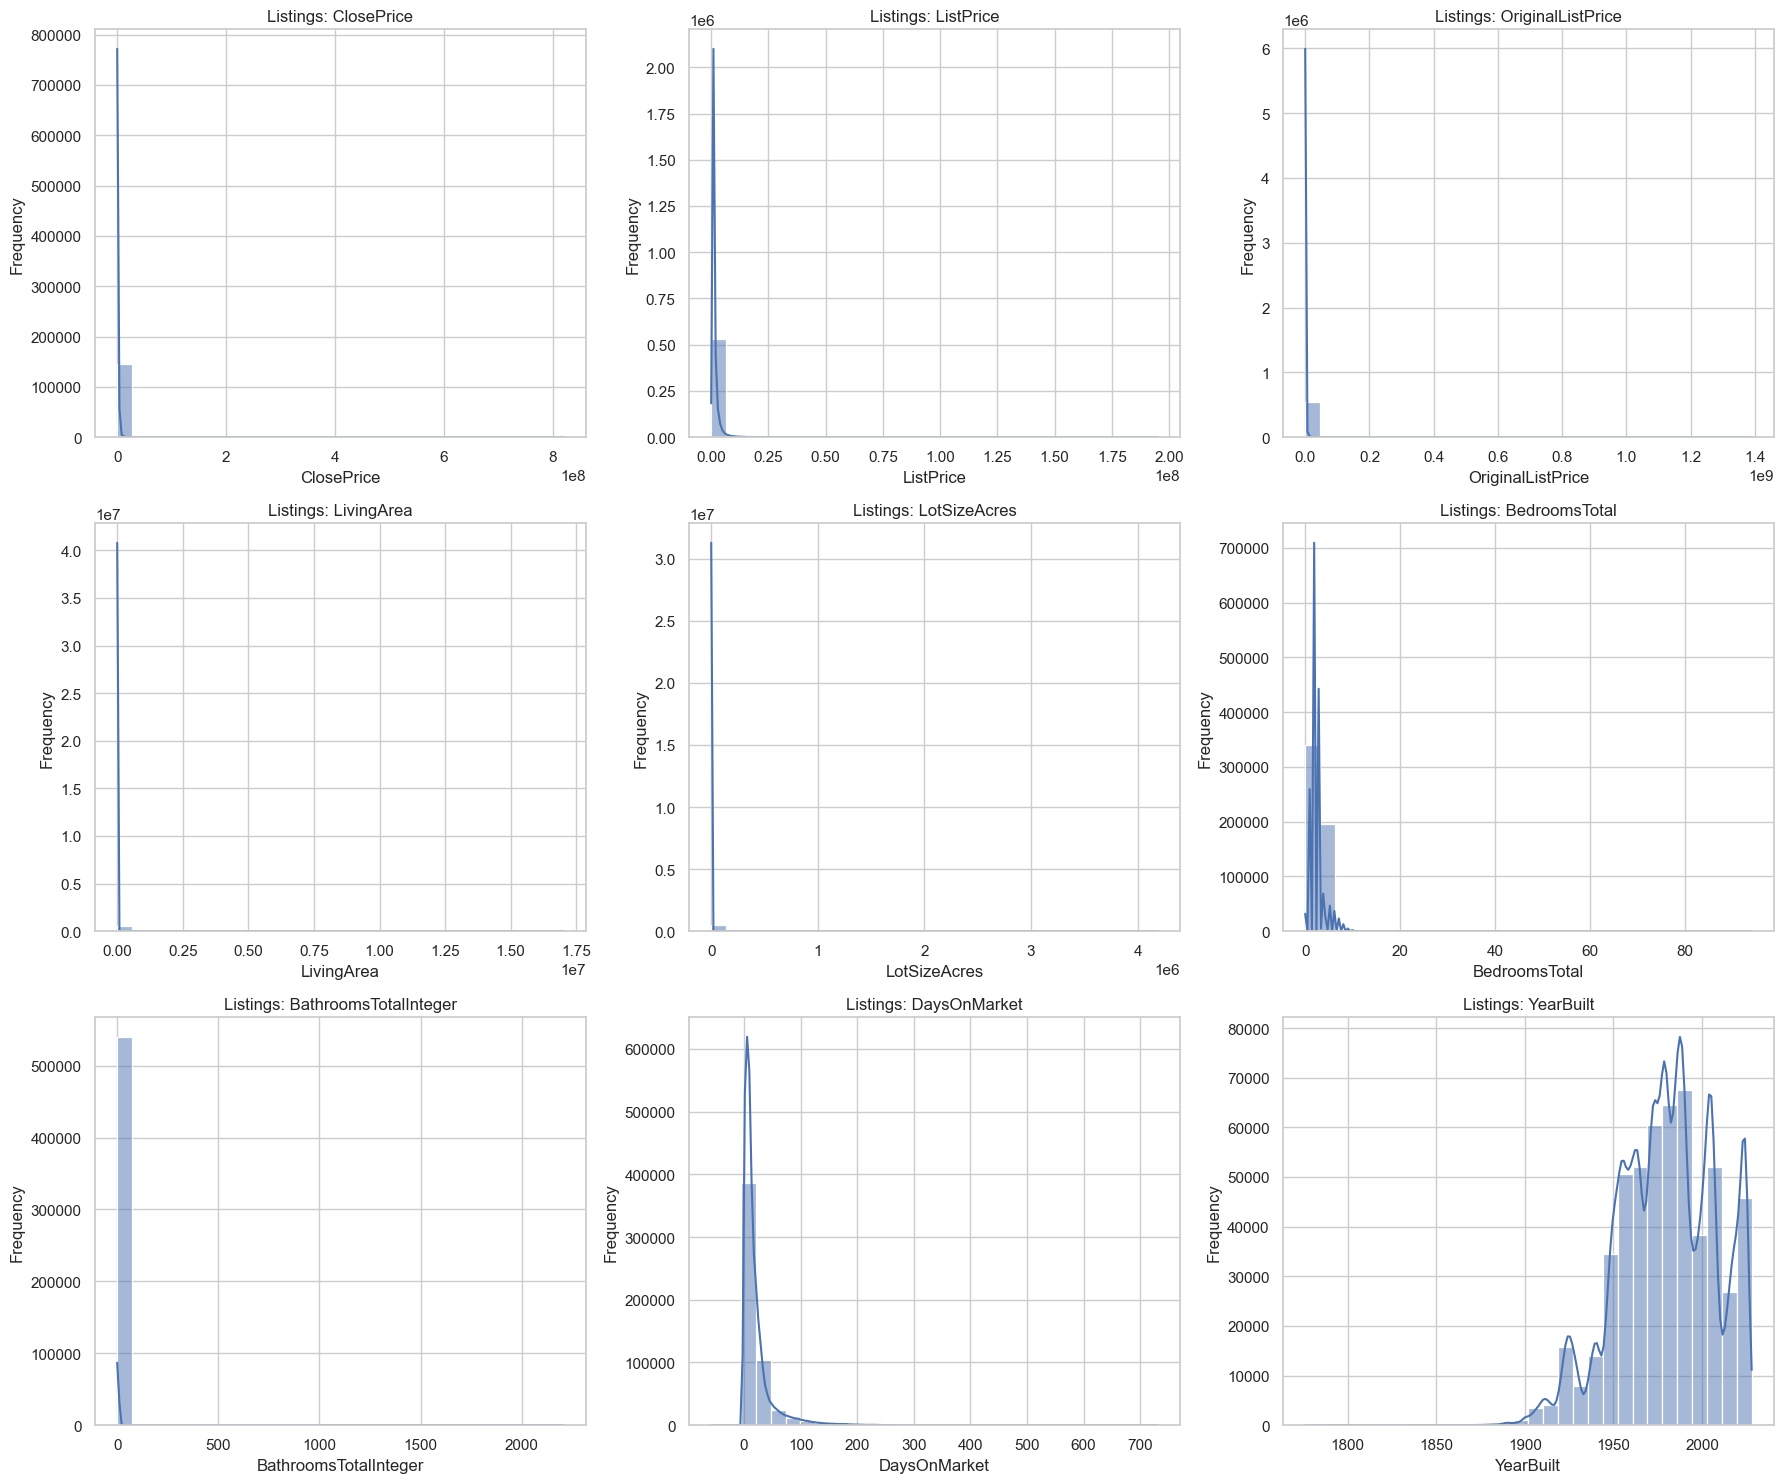

In [19]:
plot_histograms(listings, target_columns, "Listings")

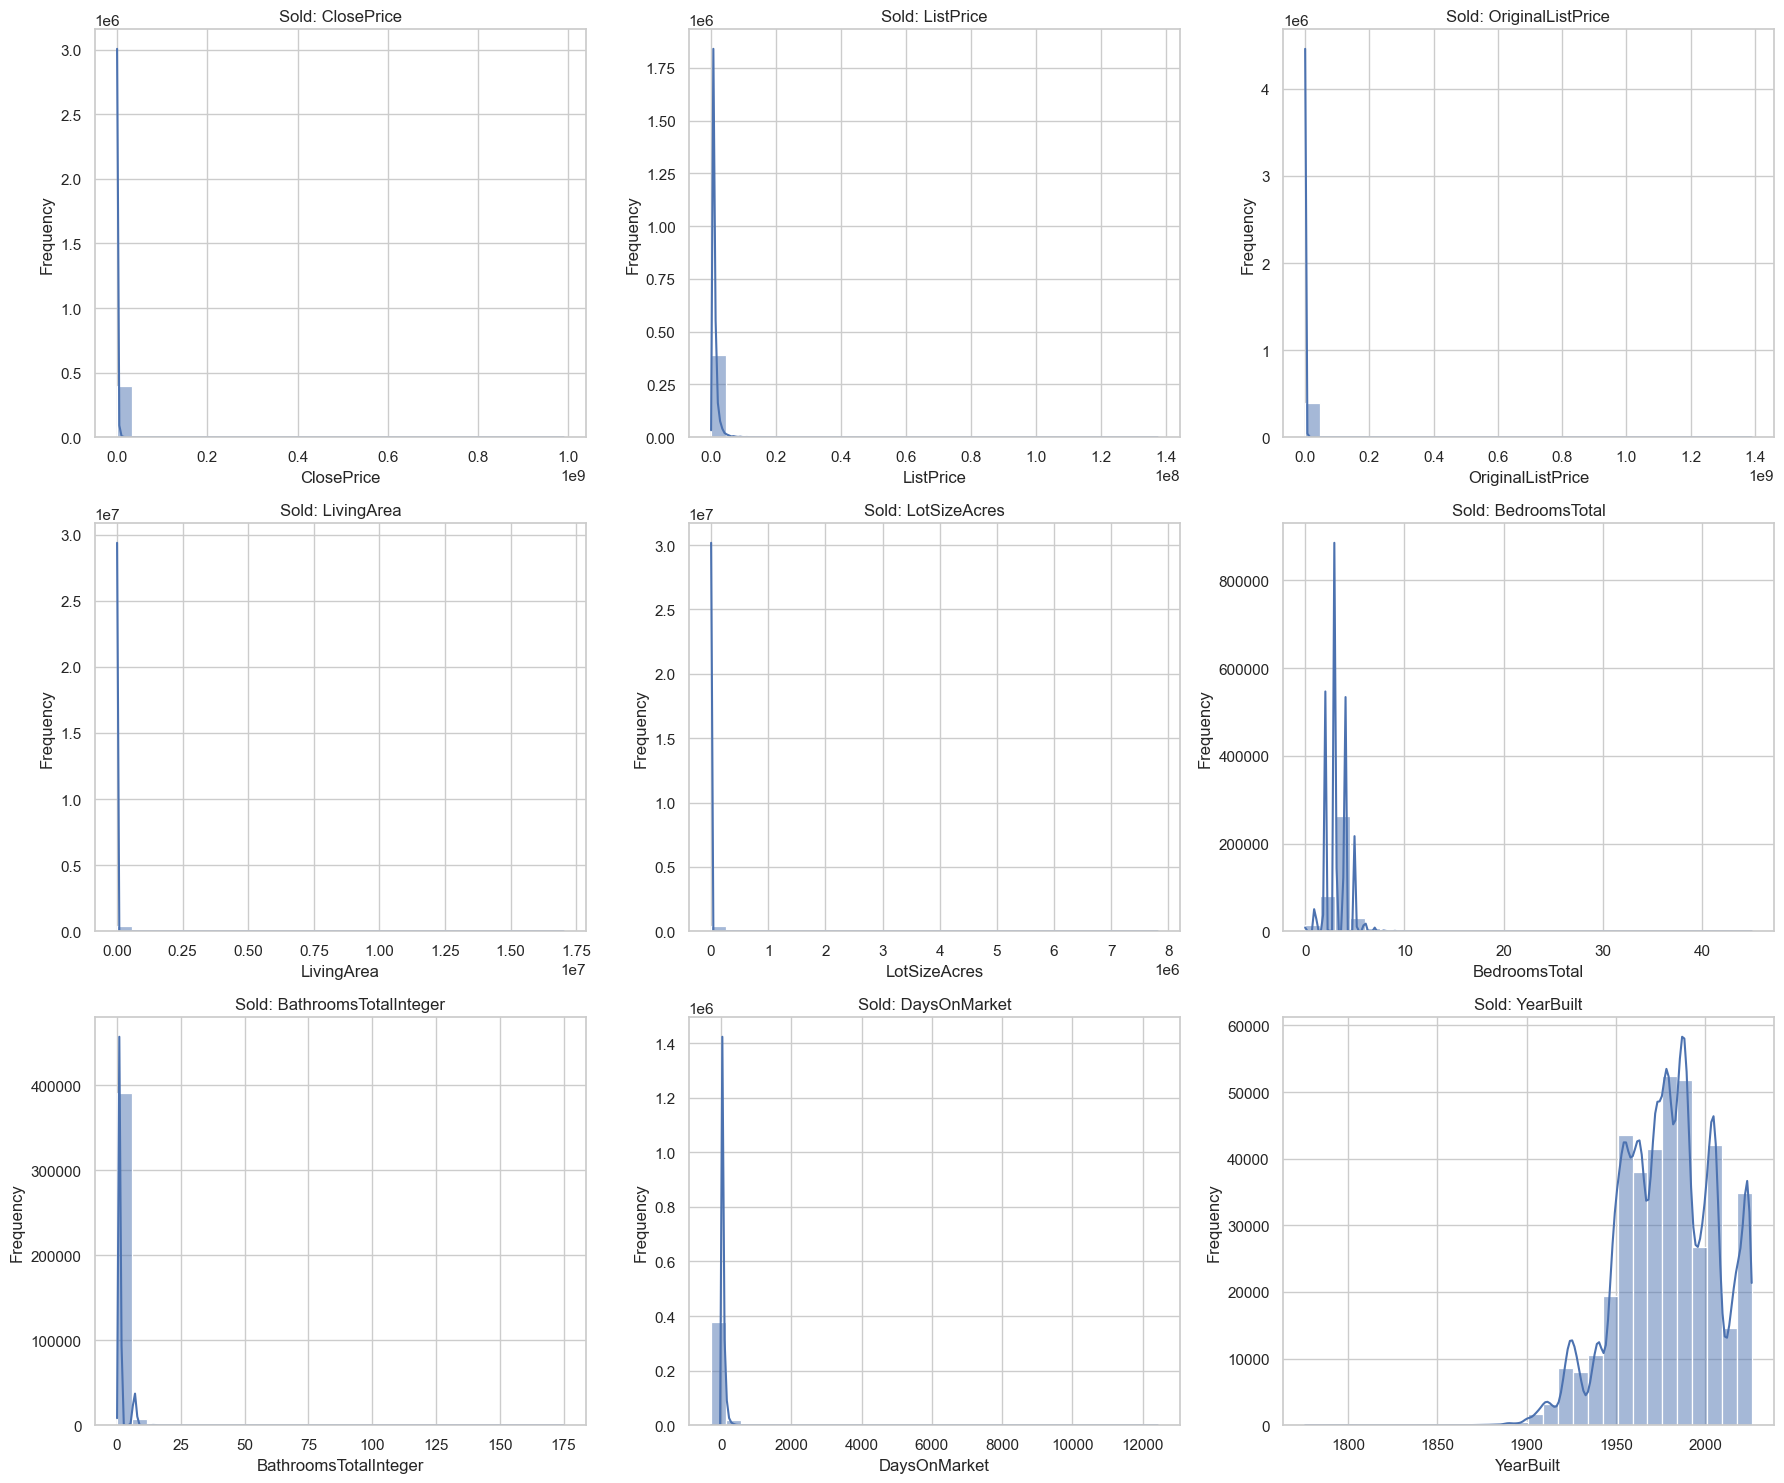

In [20]:
plot_histograms(sold, target_columns, "Sold")

#### iii) Generate percentile summaries

In [21]:
listing_cols = [col for col in target_columns if col in listings.columns]

listing_percentiles = listings[listing_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print("Listings Percentile Summary")
print(listing_percentiles)

Listings Percentile Summary
                          count          mean           std     min        1%  \
ClosePrice             145580.0  1.202136e+06  4.292686e+06   525.0  215000.0   
ListPrice              540183.0  1.312997e+06  2.346687e+06   100.0  210000.0   
OriginalListPrice      539409.0  1.397125e+06  7.357159e+06     0.0  200000.0   
LivingArea             539627.0  1.980059e+03  2.338269e+04     0.0     588.0   
LotSizeAcres           495665.0  6.523781e+01  1.213681e+04     0.0       0.0   
BedroomsTotal          540035.0  3.222963e+00  1.186992e+00     0.0       1.0   
BathroomsTotalInteger  540128.0  2.626022e+00  3.258017e+00     0.0       1.0   
DaysOnMarket           540183.0  1.953990e+01  2.677115e+01   -58.0       0.0   
YearBuilt              539244.0  1.979605e+03  2.699438e+01  1776.0    1911.0   

                                5%        25%        50%          75%  \
ClosePrice             355000.0000  600000.00  855000.00  1350000.000   
ListPrice      

In [22]:
sold_cols = [col for col in target_columns if col in sold.columns]

sold_percentiles = sold[sold_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

print("Sold Percentile Summary")
print(sold_percentiles)

Sold Percentile Summary
                          count          mean           std     min        1%  \
ClosePrice             397601.0  1.185616e+06  5.922380e+06     0.0  203000.0   
ListPrice              397603.0  1.138630e+06  1.353707e+06   525.0  214990.1   
OriginalListPrice      396882.0  1.224737e+06  6.779804e+06     0.0  210405.0   
LivingArea             397374.0  1.904351e+03  2.701781e+04     0.0     604.0   
LotSizeAcres           366239.0  6.855894e+01  1.632724e+04     0.0       0.0   
BedroomsTotal          397592.0  3.200200e+00  1.067419e+00     0.0       1.0   
BathroomsTotalInteger  397534.0  2.533185e+00  1.135979e+00     0.0       1.0   
DaysOnMarket           397603.0  3.733679e+01  5.353925e+01  -288.0       0.0   
YearBuilt              397247.0  1.978568e+03  2.627278e+01  1776.0    1912.0   

                              5%        25%          50%           75%  \
ClosePrice             340000.00  575000.00  820000.0000  1.300000e+06   
ListPrice        

#### iv) Identify extreme outliers

In [23]:
# Outliers in Listings

for col in target_columns:
    if col in listings.columns:
        listings = flag_outliers(listings, col)

ClosePrice: 10,480 outliers flagged (1.9%) — bounds [-525,000.00, 2,475,000.00]
ListPrice: 45,490 outliers flagged (8.4%) — bounds [-612,500.00, 2,567,500.00]
OriginalListPrice: 45,336 outliers flagged (8.4%) — bounds [-621,000.00, 2,595,000.00]
LivingArea: 26,718 outliers flagged (4.9%) — bounds [-332.50, 3,879.50]
LotSizeAcres: 79,445 outliers flagged (14.7%) — bounds [-0.17, 0.60]
BedroomsTotal: 1,735 outliers flagged (0.3%) — bounds [-1.00, 7.00]
BathroomsTotalInteger: 34,223 outliers flagged (6.3%) — bounds [0.50, 4.50]
DaysOnMarket: 45,168 outliers flagged (8.4%) — bounds [-22.00, 50.00]
YearBuilt: 1,365 outliers flagged (0.3%) — bounds [1,901.00, 2,061.00]


In [24]:
# Outliers for Sold

for col in target_columns:
    if col in sold.columns:
        sold = flag_outliers(sold, col)

ClosePrice: 29,410 outliers flagged (7.4%) — bounds [-512,500.00, 2,387,500.00]
ListPrice: 29,578 outliers flagged (7.4%) — bounds [-505,000.00, 2,375,000.00]
OriginalListPrice: 30,860 outliers flagged (7.8%) — bounds [-486,000.00, 2,370,000.00]
LivingArea: 17,540 outliers flagged (4.4%) — bounds [-208.00, 3,672.00]
LotSizeAcres: 56,982 outliers flagged (14.3%) — bounds [-0.11, 0.50]
BedroomsTotal: 21,913 outliers flagged (5.5%) — bounds [1.50, 5.50]
BathroomsTotalInteger: 18,245 outliers flagged (4.6%) — bounds [0.50, 4.50]
DaysOnMarket: 30,269 outliers flagged (7.6%) — bounds [-52.00, 108.00]
YearBuilt: 942 outliers flagged (0.2%) — bounds [1,901.50, 2,057.50]


#### v) Check for invalid numeric values and remove them from the dataset
- if ClosePrice <= 0
- if LivingArea <= 0
- if DaysOnMarket < 0
- if BathroomsTotalInteger < 0
- if BedroomsTotal < 0

In [25]:
# Check and remove invalid rows in listings
invalid_numeric_rows_listings = (
    (listings["ClosePrice"] <= 0) |
    (listings["LivingArea"] <= 0) |
    (listings["DaysOnMarket"] < 0) |
    (listings["BathroomsTotalInteger"] < 0) |
    (listings["BedroomsTotal"] < 0))

print(f"Listings rows meeting at least one invalid-condition check: {invalid_numeric_rows_listings.sum()}")

Listings rows meeting at least one invalid-condition check: 388


In [26]:
# Remove invalid rows
listings = listings[~invalid_numeric_rows_listings]

print(f"Listings shape after removing invalid rows: {listings.shape}")

Listings shape after removing invalid rows: (539795, 69)


In [27]:
# Check and remove invalid rows in listings
invalid_numeric_rows_sold = (
    (sold["ClosePrice"] <= 0) |
    (sold["LivingArea"] <= 0) |
    (sold["DaysOnMarket"] < 0) |
    (sold["BathroomsTotalInteger"] < 0) |
    (sold["BedroomsTotal"] < 0))

print(f"Sold rows meeting at least one invalid-condition check: {invalid_numeric_rows_sold.sum()}")

Sold rows meeting at least one invalid-condition check: 191


In [28]:
# Remove invalid rows

sold = sold[~invalid_numeric_rows_sold]

print(f"Sold shape: {sold.shape[0]:,} rows x {sold.shape[1]} columns")

Sold shape: 397,412 rows x 76 columns


# 3. Feature Engineering

### 3a) Date Time features
Create year/month features from date columns

In [29]:
# Listings date columns

listings_date_cols = [col for col in listings.columns if "date" in col.lower()]
print("Listings Date Columns", listings_date_cols)

Listings Date Columns ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']


In [30]:
# Create the Listings date features

for col in listings_date_cols:
    listings[col] = pd.to_datetime(listings[col], errors="coerce")
    base_name = col.replace("Date", "").lower()

    listings[f"{base_name}_year"] = listings[col].dt.year
    listings[f"{base_name}_month"] = listings[col].dt.month
    listings[f"{base_name}_day"] = listings[col].dt.day
    listings[f"{base_name}_yrmoday"] = (
        listings[f"{base_name}_year"] * 10000
        + listings[f"{base_name}_month"] * 100
        + listings[f"{base_name}_day"])

    print(f"{col} date range:", listings[col].min().date(), "to", listings[col].max().date())

CloseDate date range: 2024-01-01 to 2030-04-16
ContractStatusChangeDate date range: 2024-01-01 to 2026-04-30
PurchaseContractDate date range: 2023-06-13 to 2026-04-17
ListingContractDate date range: 2024-01-01 to 2026-03-31


In [31]:
# Sold date columns

sold_date_cols = [col for col in sold.columns if "date" in col.lower()]
print("Sold Date Columns", sold_date_cols)

Sold Date Columns ['CloseDate', 'ContractStatusChangeDate', 'PurchaseContractDate', 'ListingContractDate']


In [32]:
# Create the Sold date features

for col in sold_date_cols:
    sold[col] = pd.to_datetime(sold[col], errors="coerce")
    base_name = col.replace("Date", "").lower()

    sold[f"{base_name}_year"] = sold[col].dt.year
    sold[f"{base_name}_month"] = sold[col].dt.month
    sold[f"{base_name}_day"] = sold[col].dt.day
    sold[f"{base_name}_yrmoday"] = (
        sold[f"{base_name}_year"] * 10000
        + sold[f"{base_name}_month"] * 100
        + sold[f"{base_name}_day"])

    print(f"{col} date range:", sold[col].min().date(), "to", sold[col].max().date())

CloseDate date range: 2024-01-01 to 2026-03-31
ContractStatusChangeDate date range: 2024-01-01 to 2026-03-31
PurchaseContractDate date range: 1923-11-16 to 2026-03-31
ListingContractDate date range: 1984-08-28 to 2026-03-31


#### i) Date Consistency Checks
Are there any apparent date consistency issues (e.g., close date before listing date)?

In [33]:
listing_date_consistency_checks = {
    # Is the close date before the listing date?
    "CloseDate before ListingContractDate": listings["close_yrmoday"] < listings["listingcontract_yrmoday"],

    # Is the purchase contract date before the listing date?
    "PurchaseContractDate before ListingContractDate": listings["purchasecontract_yrmoday"] < listings["listingcontract_yrmoday"],

    # Is the close date before the purchase contract date?
    "CloseDate before PurchaseContractDate": listings["close_yrmoday"] < listings["purchasecontract_yrmoday"],

    # Is the contract status change date before the listing date?
    "ContractStatusChangeDate before ListingContractDate": listings["contractstatuschange_yrmoday"] < listings["listingcontract_yrmoday"],}

print("\nListings date consistency checks:")
for check_name, condition in listing_date_consistency_checks.items():
    print(f"{check_name}: {condition.sum()} rows")


Listings date consistency checks:
CloseDate before ListingContractDate: 72 rows
PurchaseContractDate before ListingContractDate: 270 rows
CloseDate before PurchaseContractDate: 265 rows
ContractStatusChangeDate before ListingContractDate: 128 rows


We should drop the rows with these date inconsistencies before further analysis to avoid tainting the results.

In [34]:
sold_date_consistency_checks = {
    # Is the close date before the listing date?
    "CloseDate before ListingContractDate": sold["close_yrmoday"] < sold["listingcontract_yrmoday"],

    # Is the purchase contract date before the listing date?
    "PurchaseContractDate before ListingContractDate": sold["purchasecontract_yrmoday"] < sold["listingcontract_yrmoday"],

    # Is the close date before the purchase contract date?
    "CloseDate before PurchaseContractDate": sold["close_yrmoday"] < sold["purchasecontract_yrmoday"],

    # Is the contract status change date before the listing date?
    "ContractStatusChangeDate before ListingContractDate": sold["contractstatuschange_yrmoday"] < sold["listingcontract_yrmoday"],}

print("Sold date consistency checks:")
for check_name, condition in sold_date_consistency_checks.items():
    print(f"{check_name}: {condition.sum()} rows")

Sold date consistency checks:
CloseDate before ListingContractDate: 58 rows
PurchaseContractDate before ListingContractDate: 260 rows
CloseDate before PurchaseContractDate: 240 rows
ContractStatusChangeDate before ListingContractDate: 58 rows


In [35]:
# Drop inconsistent date rows for Listings

bad_date_rows_listings = (
    (listings["close_yrmoday"] < listings["listingcontract_yrmoday"]) |
    (listings["purchasecontract_yrmoday"] < listings["listingcontract_yrmoday"]) |
    (listings["close_yrmoday"] < listings["purchasecontract_yrmoday"]) |
    (listings["contractstatuschange_yrmoday"] < listings["listingcontract_yrmoday"]))

print(f"Rows in Listings with date inconsistencies: {bad_date_rows_listings.sum()}")

# Remove inconsistent date rows
listings = listings[~bad_date_rows_listings]

Rows in Listings with date inconsistencies: 537


In [36]:
# Drop inconsistent date rows for Sold

bad_date_rows_sold = (
    (sold["close_yrmoday"] < sold["listingcontract_yrmoday"]) |
    (sold["purchasecontract_yrmoday"] < sold["listingcontract_yrmoday"]) |
    (sold["close_yrmoday"] < sold["purchasecontract_yrmoday"]) |
    (sold["contractstatuschange_yrmoday"] < sold["listingcontract_yrmoday"]))

print(f"Rows in Sold with date inconsistencies: {bad_date_rows_sold.sum()}")

# Remove inconsistent date rows
sold = sold[~bad_date_rows_sold]

Rows in Sold with date inconsistencies: 500


### 3b) Geographic data checks
Flag rows with missing coordinates, latitude or longitude = 0, longitude > 0, and out-of-state or implausible coordinates.

The plausible range for coordinates for California are as follows:
- Latitude = 32 to 42 degrees
- Longitude = -125 to -114 degrees

In [37]:
# Ranges for plausible California coordinates
min_lat = 32
max_lat = 42
min_long = -125
max_long = -114

# Function for checking each geographic consistency
def geographic_consistency_check(df, df_name):
    null_lat = df["Latitude"].isna()
    null_long = df["Longitude"].isna()

    lat_zero = df["Latitude"] == 0
    long_zero = df["Longitude"] == 0

    long_positive = df["Longitude"] > 0

    lat_out_of_range = (df["Latitude"] < min_lat) | (df["Latitude"] > max_lat)
    long_out_of_range = (df["Longitude"] < min_long) | (df["Longitude"] > max_long)

    print(f"{df_name} Geographic Consistency Checks:")
    print(f"Null Latitude: {null_lat.sum()} rows")
    print(f"Null Longitude: {null_long.sum()} rows")
    print(f"Latitude = 0: {lat_zero.sum()} rows")
    print(f"Longitude = 0: {long_zero.sum()} rows")
    print(f"Longitude > 0: {long_positive.sum()} rows")
    print(f"Latitude outside plausible CA range: {lat_out_of_range.sum()} rows")
    print(f"Longitude outside plausible CA range: {long_out_of_range.sum()} rows")

    any_geo_inconsistencies = (null_lat | null_long | lat_zero | long_zero | long_positive | lat_out_of_range | long_out_of_range)

    print(f"Rows with any geographic inconsistencies: {any_geo_inconsistencies.sum()} rows")

    return any_geo_inconsistencies

In [38]:
# Listings geographic check
listings_geo_check = geographic_consistency_check(listings, "Listings")

Listings Geographic Consistency Checks:
Null Latitude: 79959 rows
Null Longitude: 79959 rows
Latitude = 0: 60 rows
Longitude = 0: 60 rows
Longitude > 0: 85 rows
Latitude outside plausible CA range: 191 rows
Longitude outside plausible CA range: 252 rows
Rows with any geographic inconsistencies: 80247 rows


In [39]:
# Sold geographic check
sold_geo_check = geographic_consistency_check(sold, "Sold")

Sold Geographic Consistency Checks:
Null Latitude: 15737 rows
Null Longitude: 15737 rows
Latitude = 0: 25 rows
Longitude = 0: 25 rows
Longitude > 0: 29 rows
Latitude outside plausible CA range: 46 rows
Longitude outside plausible CA range: 77 rows
Rows with any geographic inconsistencies: 15821 rows


I've decided simply to flag the inconsistent geographic rows instead of dropping them, since those rows may still contain useful information in other analysis columns. However, for my analyses on strictly geographical features, I will be dropping the invalid rows.

### 3c) Create Price Ratio column

For parts 3c to 3f, we only create the new features for the sold dataset.

In [40]:
sold["PriceRatio"] = sold["ClosePrice"] / sold["OriginalListPrice"]

### 3d) Create Price per Square Feet column

In [41]:
sold["Price_per_sqft"] = sold["ClosePrice"] / sold["LivingArea"]

### 3e) Add DaysOnMarket buckets

In [42]:
add_dom_buckets(listings)
add_dom_buckets(sold)

DOM buckets: {'0-7': 164977, '8-14': 131493, '15-30': 126039, '31-60': 54059, '61-90': 17728, '90+': 17330}
DOM buckets: {'0-7': 80998, '8-14': 77660, '15-30': 75201, '31-60': 70339, '61-90': 34886, '90+': 42465}


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,purchasecontract_month,purchasecontract_day,purchasecontract_yrmoday,listingcontract_year,listingcontract_month,listingcontract_day,listingcontract_yrmoday,PriceRatio,Price_per_sqft,dom_bucket
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",1,0,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,11.0,22.0,20231122.0,2021.0,10.0,6.0,20211006.0,0.480962,210.526316,90+
1,SanDiego,SanDiego,NaN,0,0,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,6.0,30.0,20210630.0,2021.0,3.0,8.0,20210308.0,1.072510,412.867275,31-60
2,SanDiego,SanDiego,NaN,0,0,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,11.0,18.0,20211118.0,2021.0,3.0,8.0,20210308.0,1.094743,410.334347,90+
4,Southland,Southland,NaN,0,0,1890500.0,1075037759,karen.klein@theagencyre.com,2024-01-29,1890500.0,...,1.0,29.0,20240129.0,2024.0,1.0,29.0,20240129.0,1.000000,591.891046,NaN
5,NorthSanLuisObispo,NorthSanLuisObispo,NaN,1,0,2100000.0,1067652762,jenniferarielkennedy@gmail.com,2024-01-02,2100000.0,...,11.0,15.0,20231115.0,2023.0,11.0,15.0,20231115.0,1.000000,562.098501,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
397598,InlandValleys,InlandValleys,"Carpet,Stone,Tile",1,0,34000000.0,1048452308,NaN,2026-03-10,3100000.0,...,1.0,30.0,20260130.0,2023.0,11.0,16.0,20231116.0,0.091176,483.543909,90+
397599,HighDesert,HighDesert,NaN,1,0,470000.0,1045564874,NaN,2026-03-20,390000.0,...,1.0,12.0,20260112.0,2023.0,9.0,21.0,20230921.0,0.829787,162.500000,90+
397600,Mrmls,TheInlandGateway,"Carpet,Vinyl",1,0,375000.0,1037668743,NaN,2026-03-30,365000.0,...,1.0,31.0,20260131.0,2023.0,5.0,21.0,20230521.0,0.973333,302.653400,90+
397601,CaliforniaDesert,CaliforniaDesert,"Stone,Wood",1,0,525000.0,1037643293,NaN,2026-03-13,410000.0,...,2.0,13.0,20260213.0,2023.0,5.0,19.0,20230519.0,0.780952,512.500000,90+


### 3f) Create the following columns:
- Close to Original List Price Ratio
- Listing to Contract Days
- Contract to Close Days

In [43]:
# Close to Original List Price Ratio
sold["Close_List_Ratio"] = sold["ClosePrice"] / sold["OriginalListPrice"]

In [44]:
# Listing to Contract Days
sold["Listing_to_Contract_Days"] = (sold["PurchaseContractDate"] - sold["ListingContractDate"])

# Check if it correctly calcuated the days in between
print(sold[["ListingContractDate", "PurchaseContractDate", "Listing_to_Contract_Days"]].head())

  ListingContractDate PurchaseContractDate Listing_to_Contract_Days
0          2021-10-06           2023-11-22                 777 days
1          2021-03-08           2021-06-30                 114 days
2          2021-03-08           2021-11-18                 255 days
4          2024-01-29           2024-01-29                   0 days
5          2023-11-15           2023-11-15                   0 days


In [45]:
# Contract to Close Days
sold["Contract_to_Close_Days"] = (sold["CloseDate"] - sold["PurchaseContractDate"])

# Check if it correctly calcuated the days in between
print(sold[["CloseDate", "PurchaseContractDate", "Contract_to_Close_Days"]].head())

   CloseDate PurchaseContractDate Contract_to_Close_Days
0 2024-01-26           2023-11-22                65 days
1 2024-01-05           2021-06-30               919 days
2 2024-01-05           2021-11-18               778 days
4 2024-01-29           2024-01-29                 0 days
5 2024-01-02           2023-11-15                48 days


# 4. Exploratory Data Analysis

#### 4a) What are the median and average close prices?

In [46]:
sold_median_closeprice = sold['ClosePrice'].median()

print(f"Median Close Price = ${sold_median_closeprice:.2f}")

Median Close Price = $820000.00


In [47]:
sold_mean_closeprice = sold['ClosePrice'].mean()

print(f"Average Close Price = ${sold_mean_closeprice:.2f}")

Average Close Price = $1183785.74


#### 4b) What percentage of homes sold above vs. below list price?

In [48]:
percent_sold_above = (sum(sold['ClosePrice'] > sold['ListPrice']) / len(sold))*100

percent_sold_below = (sum(sold['ClosePrice'] < sold['ListPrice']) / len(sold))*100

print(f"Percent sold above list price {percent_sold_above:.2f}%")
print(f"Percent sold below list price {percent_sold_below:.2f}%")


Percent sold above list price 40.14%
Percent sold below list price 42.58%


#### 4c) Which counties have the highest median prices?

In [73]:
# Check which counties are the most popular

top_counties = sold["CountyOrParish"].value_counts(dropna=False)

top_counties.head(10)

CountyOrParish
Los Angeles       98836
Riverside         55027
San Diego         48974
Orange            44733
San Bernardino    37129
Alameda           18752
Contra Costa      18093
Santa Clara       17862
Ventura           12324
San Mateo          7004
Name: count, dtype: int64

In [49]:
median_listprice_by_county_df = (
    sold.groupby("CountyOrParish", as_index=False)["ListPrice"]
    .median()
    .rename(columns={"ListPrice": "MedianListPrice"})
    .sort_values("MedianListPrice", ascending=True))

#print(median_listprice_by_county_df.to_string(index=False))

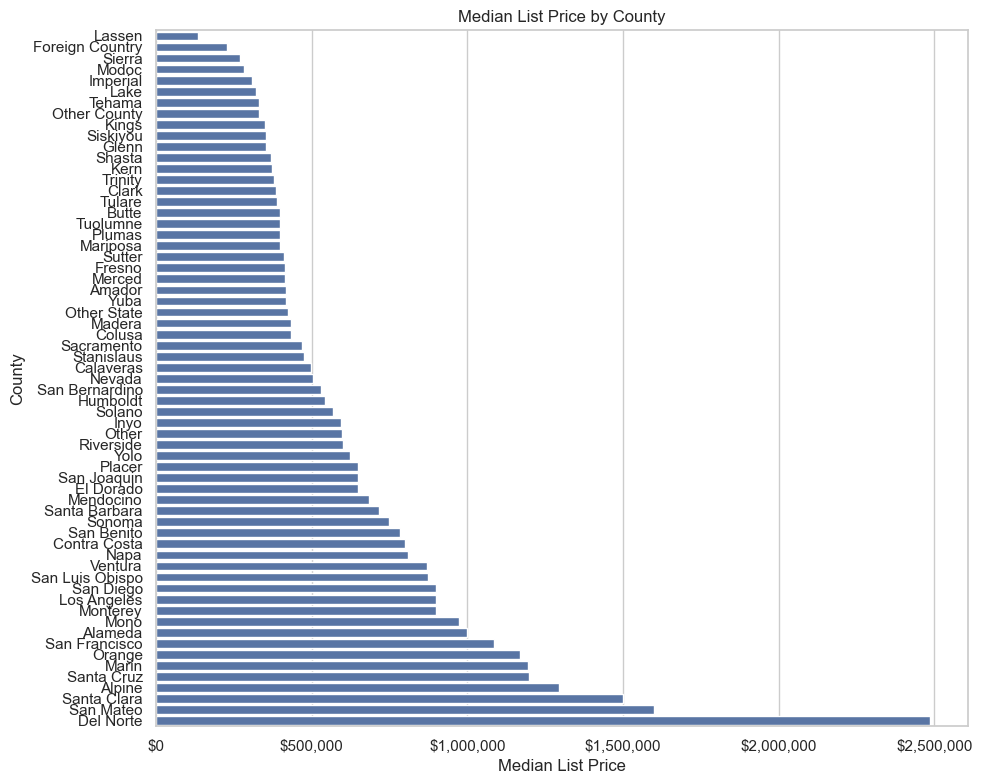

In [50]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=median_listprice_by_county_df,
    x="MedianListPrice",
    y="CountyOrParish")

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))

plt.title("Median List Price by County")
plt.xlabel("Median List Price")
plt.ylabel("County")
plt.tight_layout()
plt.show()

#### 4d) Check which offices are the most popular

In [70]:
list_office_counts = sold["ListOfficeName"].value_counts(dropna=False)

list_office_counts.head(10)

ListOfficeName
Compass                                                  27813
Coldwell Banker Realty                                   17965
Keller Williams Realty                                    7807
First Team Real Estate                                    5540
Berkshire Hathaway HomeServices California Properties     5282
eXp Realty of California Inc                              4635
Real Broker                                               4489
Intero Real Estate Services                               4399
eXp Realty of California, Inc.                            3455
Equity Union                                              3323
Name: count, dtype: int64

In [71]:
buyer_office_counts = sold["BuyerOfficeName"].value_counts(dropna=False)

buyer_office_counts.head(10)

BuyerOfficeName
Compass                                                  25930
Coldwell Banker Realty                                   14385
NONMEMBER MRML                                            8367
NaN                                                       6538
Keller Williams Realty                                    6105
Real Broker                                               5901
eXp Realty of California Inc                              5085
First Team Real Estate                                    5036
eXp Realty of California, Inc.                            4529
Berkshire Hathaway HomeServices California Properties     4133
Name: count, dtype: int64

# Mortgage Rate Enrichment

### Step 1: Fetch the mortgage rate data from FRED

In [51]:
# Libraries required to import the url file
import requests
import io
import certifi

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

# Import the mortgage file
response = requests.get(url, verify=certifi.where())
response.raise_for_status()

mortgage = pd.read_csv(io.StringIO(response.text), parse_dates=["observation_date"])
mortgage.columns = ['date', 'rate_30yr_fixed']

### Step 2: Resample weekly rates to monthly averages

In [52]:
mortgage['year_month'] = mortgage['date'].dt.to_period('M')
mortgage_monthly = (
 mortgage.groupby('year_month')['rate_30yr_fixed']
 .mean()
 .reset_index())

# Check
mortgage.head()

,date,rate_30yr_fixed,year_month
0,1971-04-02,7.33,1971-04
1,1971-04-09,7.31,1971-04
2,1971-04-16,7.31,1971-04
3,1971-04-23,7.31,1971-04
4,1971-04-30,7.29,1971-04


### Step 3: Create a matching year_month key on the MLS datasets

In [53]:
# Sold dataset — key off CloseDate
sold['year_month'] = pd.to_datetime(sold['CloseDate']).dt.to_period('M')

# Listings dataset — key off ListingContractDate
listings['year_month'] = pd.to_datetime(listings['ListingContractDate']).dt.to_period('M')

### Step 4: Merge

In [54]:
sold_with_rates = sold.merge(mortgage_monthly, on='year_month', how='left')

listings_with_rates = listings.merge(mortgage_monthly, on='year_month', how='left')

### Step 5: Validate the merge

In [55]:
# Check for any unmatched rows (rate should not be null)
print(sold_with_rates['rate_30yr_fixed'].isnull().sum())
print(listings_with_rates['rate_30yr_fixed'].isnull().sum())

# Preview
print(sold_with_rates[['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed']].head())

0
0
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01    240000.0           6.6425
1 2024-01-05    2024-01    815000.0           6.6425
2 2024-01-05    2024-01    810000.0           6.6425
3 2024-01-29    2024-01   1890500.0           6.6425
4 2024-01-02    2024-01   2100000.0           6.6425
